# 230352K Kumara K.B.R  
## Assesment 01 - Intensity Transformations and Neighborhood Filtering
#### 1 Intensity transform 

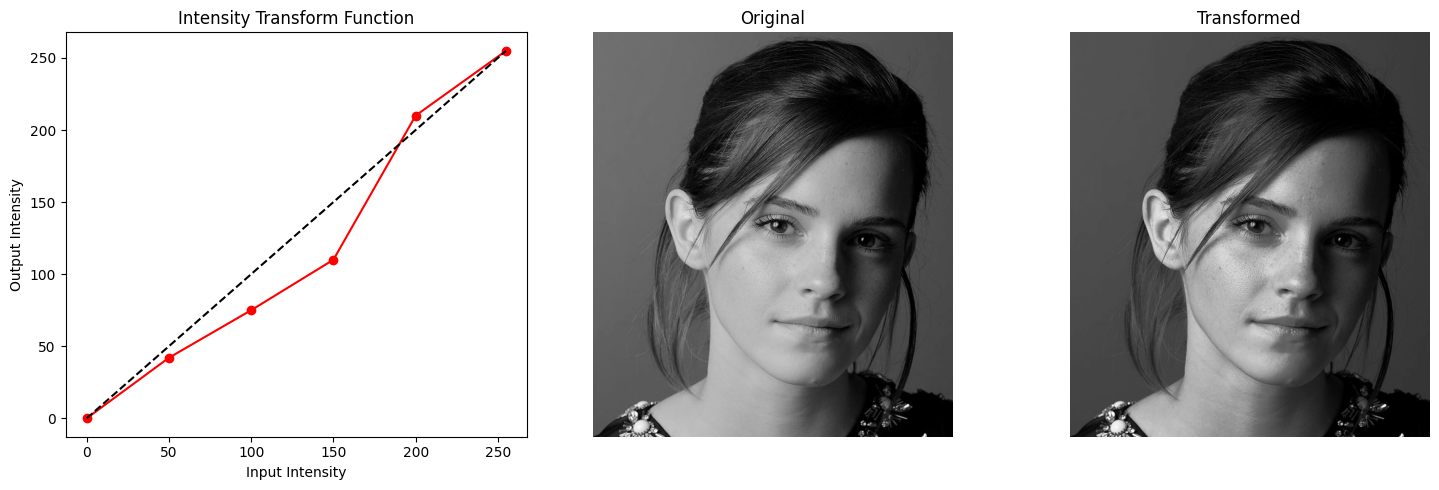

In [73]:
# importing required libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

#function to display images alongside with the intensity transform function
def show_image_3(title, image_before, image_after=None, breakpoints=None):

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    if breakpoints is not None:
        axes[0].plot(breakpoints[:, 0], breakpoints[:, 1], 'ro-')
        axes[0].plot(np.arange(256), np.arange(256), 'k--')
        axes[0].set_title("Intensity Transform Function")
        axes[0].set_xlabel("Input Intensity")
        axes[0].set_ylabel("Output Intensity")
    axes[1].imshow(image_before, cmap='gray')
    axes[1].set_title(title)
    axes[1].axis('off')
    if image_after is not None:
        axes[2].imshow(image_after, cmap='gray')
        axes[2].set_title("Transformed")
        axes[2].axis('off')
    plt.tight_layout()
    plt.show()

# Intensity transform function
def intensity_transform(im, breakpoints):
    # Create a lookup table for intensity transformation
    xp = breakpoints[:, 0]
    fp = breakpoints[:, 1]  
    lut = np.interp(np.arange(256), xp, fp).astype('uint8')
    return lut[im]

im1 = cv2.imread('images/q1.jpeg', cv2.IMREAD_GRAYSCALE) #read image in grayscale
breakpoints = np.array([[0, 0], [50, 42], [100, 75], [150, 110], [200, 210], [ 255, 255]]) #defining breakpoints for intensity transformation
transformed = intensity_transform(im1, breakpoints) #transformed image

show_image_3("Original", im1, transformed,breakpoints)


- We can see that by adjusting the breakpoints of the breakpoints array we can change the intensity transform accordingly.
- To enhance the image we can reduce the overall brighness because the image is towards more brighter area
- Adjusting the intensity transform to reduce the brighness of white pixels we can get a visually pleasing output of the image

### 2 Medical image analysis
#### we can use intensity transform to highlight gray matter and whitematter areas in MRI scan of a brain

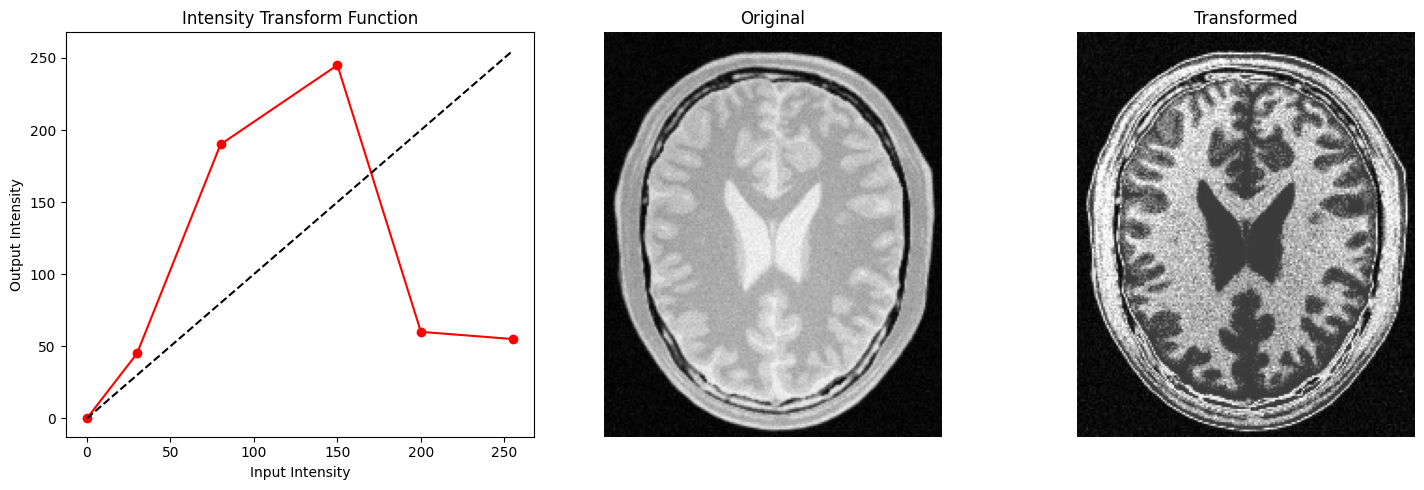

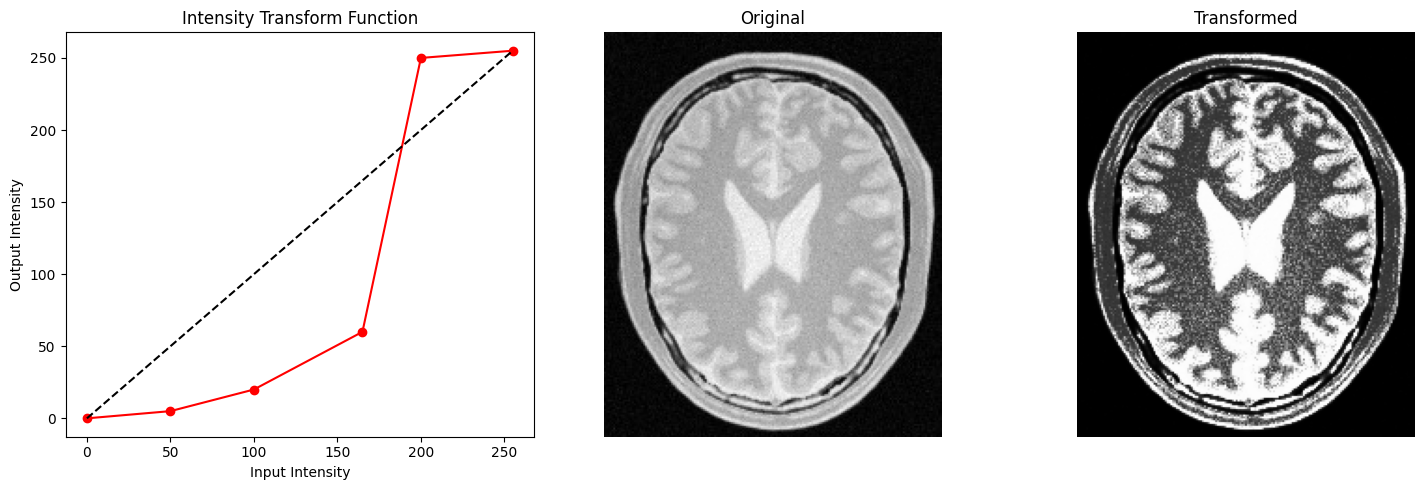

In [74]:
im2 = cv2.imread('images/q2.jpeg', cv2.IMREAD_GRAYSCALE)

white = np.array([[0, 0], [30,45], [80, 190], [150, 245],  [200, 60], [ 255, 55]]) # breakpoints for white accentuation
white_accentuated = intensity_transform(im2, white)

black = np.array([[0, 0], [50, 5], [100, 20], [165, 60],  [200, 250], [ 255, 255]]) # breakpoints for black accentuation
black_accentuated = intensity_transform(im2, black)

show_image_3("Original", im2, white_accentuated, white)
show_image_3("Original", im2, black_accentuated, black)

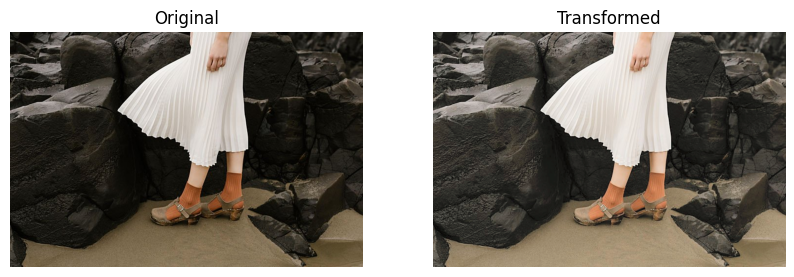

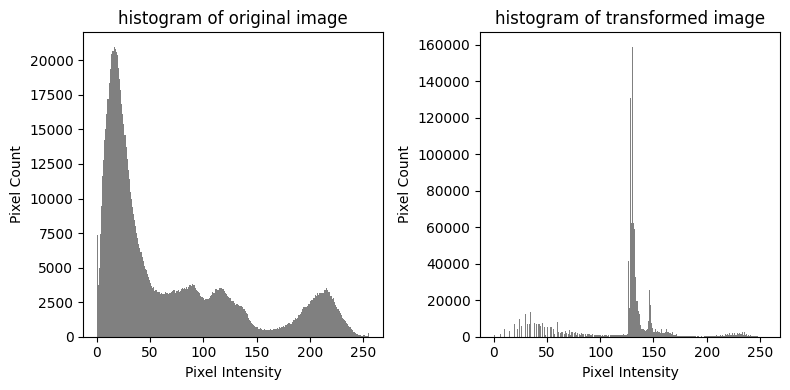

In [61]:
im3 = cv2.imread('images/q3.jpeg')
lab_image = cv2.cvtColor(im3, cv2.COLOR_BGR2LAB)
l = lab_image[:, :, 0]
gamma = 0.65
lut = np.array([((i / 255.0) ** gamma) * 255 for i in np.arange(0, 256)]).astype("uint8")
l_transformed = cv2.LUT(l, lut) 

def show_image_2(title, image_before, image_after=None):
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].imshow(image_before, cmap='gray')
    axes[0].set_title(title)
    axes[0].axis('off')
    if image_after is not None:
        axes[1].imshow(image_after, cmap='gray')
        axes[1].set_title("Transformed")
        axes[1].axis('off')
    plt.show()

img_rgb_original = cv2.cvtColor(im3, cv2.COLOR_BGR2RGB)
im3_transformed = cv2.merge((l_transformed, lab_image[:, :, 1], lab_image[:, :, 2]))
img_rgb_corrected = cv2.cvtColor(im3_transformed, cv2.COLOR_LAB2RGB)
show_image_2("Original", img_rgb_original, img_rgb_corrected)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].hist(im3.ravel(), bins=256, range=[0, 256], color='gray')
axes[0].set(title="histogram of original image", xlabel="Pixel Intensity", ylabel="Pixel Count")
axes[1].hist(im3_transformed.ravel(), bins=256, range=[0, 256], color='gray')
axes[1].set(title="histogram of transformed image", xlabel="Pixel Intensity", ylabel="Pixel Count")
plt.tight_layout()
plt.show()


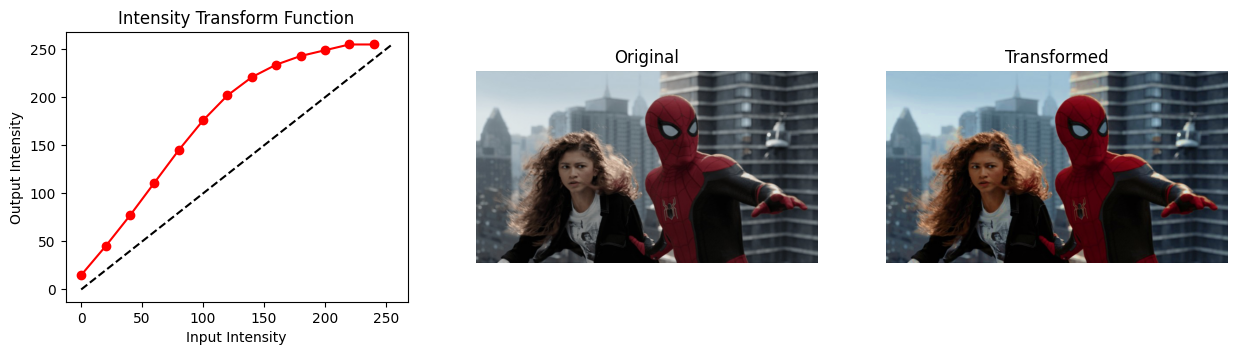

In [62]:
im4 = cv2.imread('images/q4.jpeg')
hsv_image = cv2.cvtColor(im4, cv2.COLOR_BGR2HSV)    
h, s, v = cv2.split(hsv_image)

a = 0.65    
sigma = 70
x = np.arange(256)
boost = a * 128 * np.exp(-((x - 128)**2) / (2 * sigma**2))
lut_hsv = np.minimum(x + boost, 255).astype(np.uint8)

im4_transformed = cv2.merge((h, cv2.LUT(s, lut_hsv), v))
im4_rgb_original = cv2.cvtColor(im4, cv2.COLOR_BGR2RGB)
im4_rgb_transformed = cv2.cvtColor(im4_transformed, cv2.COLOR_HSV2RGB)

curve_points = np.column_stack((x[::20], lut_hsv[::20]))

show_image_3("Original", im4_rgb_original, im4_rgb_transformed, curve_points)


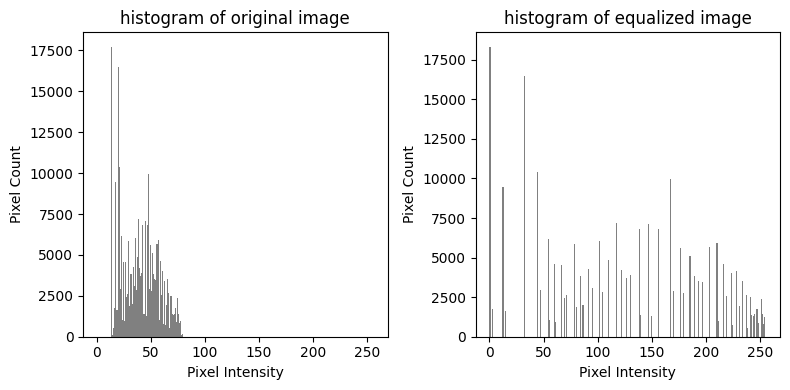

In [63]:
im5 = cv2.imread('images/q5.tif', cv2.IMREAD_GRAYSCALE)
def histogram_equalization(im):
    hist, bins = np.histogram(im.flatten(), 256, [0, 256])
    cdf = hist.cumsum()
    cdf_normalized = cdf * hist.max() / cdf.max()
    cdf_m = np.ma.masked_equal(cdf, 0)
    cdf_m = (cdf_m - cdf_m.min()) * 255 / (cdf_m.max() - cdf_m.min())
    cdf_final = np.ma.filled(cdf_m, 0).astype('uint8')
    return cdf_final[im]
equalized_image = histogram_equalization(im5)
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].hist(im5.ravel(), bins=256, range=[0, 256], color='gray')
axes[0].set(title="histogram of original image", xlabel="Pixel Intensity", ylabel="Pixel Count")
axes[1].hist(equalized_image.ravel(), bins=256, range=[0, 256], color='gray')
axes[1].set(title="histogram of equalized image", xlabel="Pixel Intensity", ylabel="Pixel Count")
plt.tight_layout()
plt.show()

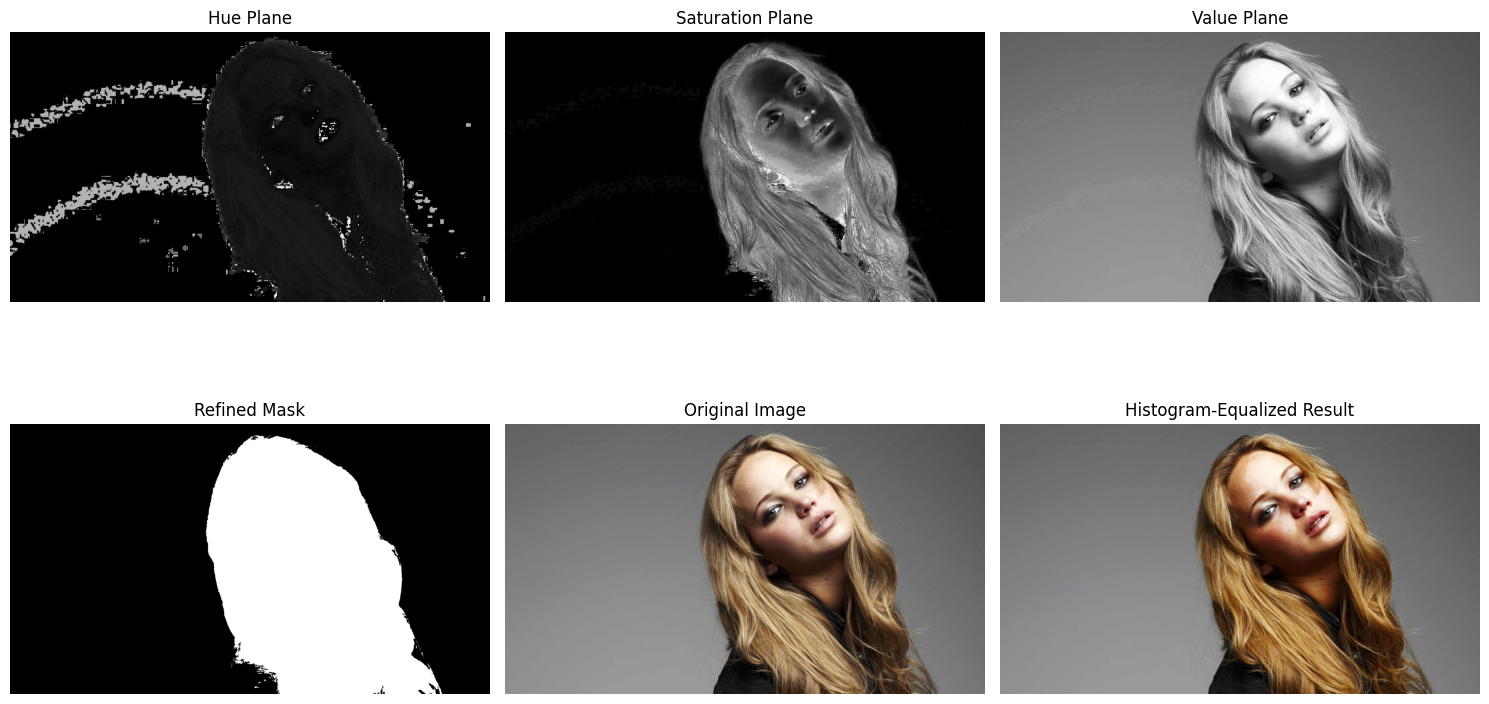

In [64]:
im6 = cv2.imread('images/q6.jpeg')
im6_hsv = cv2.cvtColor(im6, cv2.COLOR_BGR2HSV)
h, s, v = cv2.split(im6_hsv)    

img_rgb = cv2.cvtColor(im6, cv2.COLOR_BGR2RGB)
threshold_val, mask = cv2.threshold(s, 15, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

foreground = cv2.bitwise_and(img_rgb, img_rgb, mask=mask)
valid_foreground_pixels = foreground[mask == 255]

hist, bins = np.histogram(valid_foreground_pixels.ravel(), bins=256, range=[1, 256])
cdf = np.cumsum(hist)
cdf_masked = np.ma.masked_equal(cdf, 0)
cdf_normalized = ((cdf_masked - cdf_masked.min()) * 255 / (cdf_masked.max() - cdf_masked.min()))
lut = np.ma.filled(cdf_normalized, 0).astype(np.uint8)

s_equalized = cv2.LUT(s, lut)
img_hsv_eq = cv2.merge((h, s_equalized, v))
img_rgb_eq = cv2.cvtColor(img_hsv_eq, cv2.COLOR_HSV2RGB)

foreground_eq = cv2.bitwise_and(img_rgb_eq, img_rgb_eq, mask=mask)

mask_inv = cv2.bitwise_not(mask)
background = cv2.bitwise_and(img_rgb, img_rgb, mask=mask_inv)

final_image = cv2.add(foreground_eq, background)

# List of image data, titles, and colormaps
images = [h, s, v, refined_mask, img_rgb, final_image]
titles = [
    "Hue Plane",
    "Saturation Plane",
    "Value Plane",
    "Refined Mask",
    "Original Image",
    "Histogram-Equalized Result",
]
cmaps = ["gray", "gray", "gray", "gray", None, None]

# Plot all 6 outputs in a 2x3 grid
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for ax, img, title, cmap in zip(axes.flat, images, titles, cmaps):
    ax.imshow(img, cmap=cmap) if cmap else ax.imshow(img)
    ax.set_title(title, fontsize=12)
    ax.axis("off")

plt.tight_layout()
plt.show()


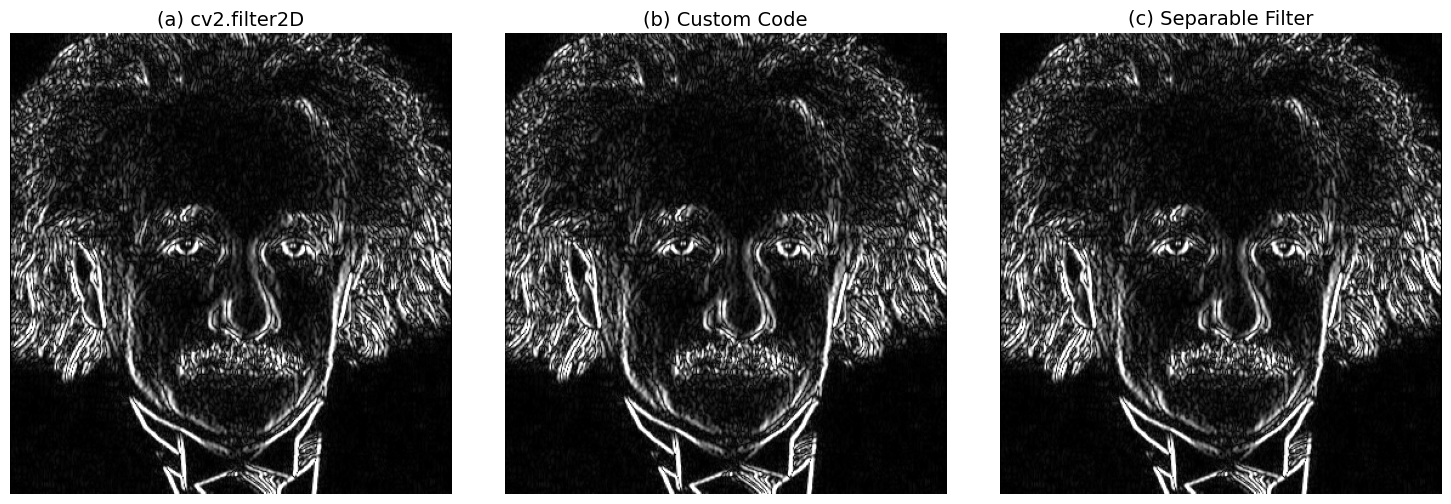

In [65]:
im7 = cv2.imread('images/q7.jpeg', cv2.IMREAD_GRAYSCALE)
sobel_kernel = np.array([[1, 0, -1],[2, 0, -2],[1, 0, -1]], dtype=np.float32)

sobel_a = cv2.filter2D(im7, cv2.CV_64F, sobel_kernel)

def custom_sobel(image, kernel):
    h, w = image.shape
    padded = np.pad(image, pad_width=1, mode='edge')
    output = np.zeros((h, w), dtype=np.float64)

    for i in range(3):
        for j in range(3):
            output += padded[i:i+h, j:j+w] * kernel[i, j]
    return output

sobel_b = custom_sobel(im7, sobel_kernel)

col_kernel = np.array([[1], [2], [1]], dtype=np.float32)
row_kernel = np.array([[1, 0, -1]], dtype=np.float32)

sobel_c_step1 = cv2.filter2D(im7, cv2.CV_64F, row_kernel)
sobel_c = cv2.filter2D(sobel_c_step1, cv2.CV_64F, col_kernel)

results = [sobel_a, sobel_b, sobel_c]
display_images = [cv2.convertScaleAbs(res) for res in results]
titles = ["(a) cv2.filter2D", "(b) Custom Code", "(c) Separable Filter"]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, img, title in zip(axes, display_images, titles):
    ax.imshow(img, cmap='gray')
    ax.set_title(title, fontsize=14)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [66]:
def zoom_image(image, s, method='bilinear'):
    
    if not (0 < s <= 10):
        raise ValueError("Scale factor s must be in range (0, 10].")

    h_in, w_in = image.shape[:2]

    h_out = int(round(h_in * s))
    w_out = int(round(w_in * s))

    out_r, out_c = np.meshgrid(np.arange(h_out), np.arange(w_out), indexing='ij')
    in_r = out_r / s
    in_c = out_c / s

    if method == 'nearest':
        r_nn = np.clip(np.round(in_r).astype(int), 0, h_in - 1)
        c_nn = np.clip(np.round(in_c).astype(int), 0, w_in - 1)
        return image[r_nn, c_nn]

    elif method == 'bilinear':
        r0 = np.clip(np.floor(in_r).astype(int), 0, h_in - 1)
        c0 = np.clip(np.floor(in_c).astype(int), 0, w_in - 1)
        r1 = np.clip(r0 + 1, 0, h_in - 1)
        c1 = np.clip(c0 + 1, 0, w_in - 1)

        dr = in_r - r0
        dc = in_c - c0

        if image.ndim == 3:
            dr = dr[:, :, np.newaxis]
            dc = dc[:, :, np.newaxis]

        i_00 = image[r0, c0]
        i_01 = image[r0, c1]
        i_10 = image[r1, c0]
        i_11 = image[r1, c1]

        zoomed = ( (1 - dr) * (1 - dc) * i_00 +
                   (1 - dr) * dc        * i_01 +
                   dr        * (1 - dc) * i_10 +
                   dr        * dc        * i_11 )

        return np.clip(zoomed, 0, 255).astype(image.dtype)
    else:
        raise ValueError("Invalid method. Choose 'nearest' or 'bilinear'.")

def compute_normalized_ssd(img1, img2):

    i1 = img1.astype(np.float64)
    i2 = img2.astype(np.float64)

    min_h = min(i1.shape[0], i2.shape[0])
    min_w = min(i1.shape[1], i2.shape[1])
    i1, i2 = i1[:min_h, :min_w], i2[:min_h, :min_w]

    ssd = np.sum((i1 - i2) ** 2)
    norm_factor = np.sqrt(np.sum(i1 ** 2) * np.sum(i2 ** 2))
    
    return ssd / norm_factor

org_1 = cv2.imread("images/im01.png")
org_1_small = cv2.imread("images/im01small.png")
org_2 = cv2.imread("images/im02.png")
org_2_small = cv2.imread("images/im02small.png")
org_3 = cv2.imread("images/im03.png")
org_3_small = cv2.imread("images/im03small.png")
org_4 = cv2.imread("images/im04.jpg")
org_4_small = cv2.imread("images/im04small.jpg")
org_5 = cv2.imread("images/im05.jpg")

zoomed_1_nearest = zoom_image(org_1_small, 4, method='nearest')
zoomed_2_nearest = zoom_image(org_2_small, 4, method='nearest')
zoomed_3_nearest = zoom_image(org_3_small, 4, method='nearest')
zoomed_4_nearest = zoom_image(org_4_small, 4, method='nearest')
zoomed_5_nearest = zoom_image(org_4, 4, method='nearest')

zoomed_1_bilinear = zoom_image(org_1_small, 4, method='bilinear')
zoomed_2_bilinear = zoom_image(org_2_small, 4, method='bilinear')
zoomed_3_bilinear = zoom_image(org_3_small, 4, method='bilinear')   
zoomed_4_bilinear = zoom_image(org_4_small, 4, method='bilinear')
zoomed_5_bilinear = zoom_image(org_4, 4, method='bilinear')

print("\nNormalized SSD for Nearest Neighbor:")
print(f"Image 1: {compute_normalized_ssd(zoomed_1_nearest, org_1)}")
print(f"Image 2: {compute_normalized_ssd(zoomed_2_nearest, org_2)}")
print(f"Image 3: {compute_normalized_ssd(zoomed_3_nearest, org_3)}")
print(f"Image 4: {compute_normalized_ssd(zoomed_4_nearest, org_4)}")
print(f"Image 5: {compute_normalized_ssd(zoomed_5_nearest, org_5)}")

print("\nNormalized SSD for Bilinear Interpolation:")
print(f"Image 1: {compute_normalized_ssd(zoomed_1_bilinear, org_1)}")
print(f"Image 2: {compute_normalized_ssd(zoomed_2_bilinear, org_2)}")
print(f"Image 3: {compute_normalized_ssd(zoomed_3_bilinear, org_3)}")   
print(f"Image 4: {compute_normalized_ssd(zoomed_4_bilinear, org_4)}")
print(f"Image 5: {compute_normalized_ssd(zoomed_5_bilinear, org_5)}")   



Normalized SSD for Nearest Neighbor:
Image 1: 0.022723755019869372
Image 2: 0.010222450796042634
Image 3: 0.014736245414124213
Image 4: 0.009568093528161205
Image 5: 0.10703546082633121

Normalized SSD for Bilinear Interpolation:
Image 1: 0.017942082873708035
Image 2: 0.007791584646435189
Image 3: 0.011208698279878731
Image 4: 0.007709435068207265
Image 5: 0.10556147403654637


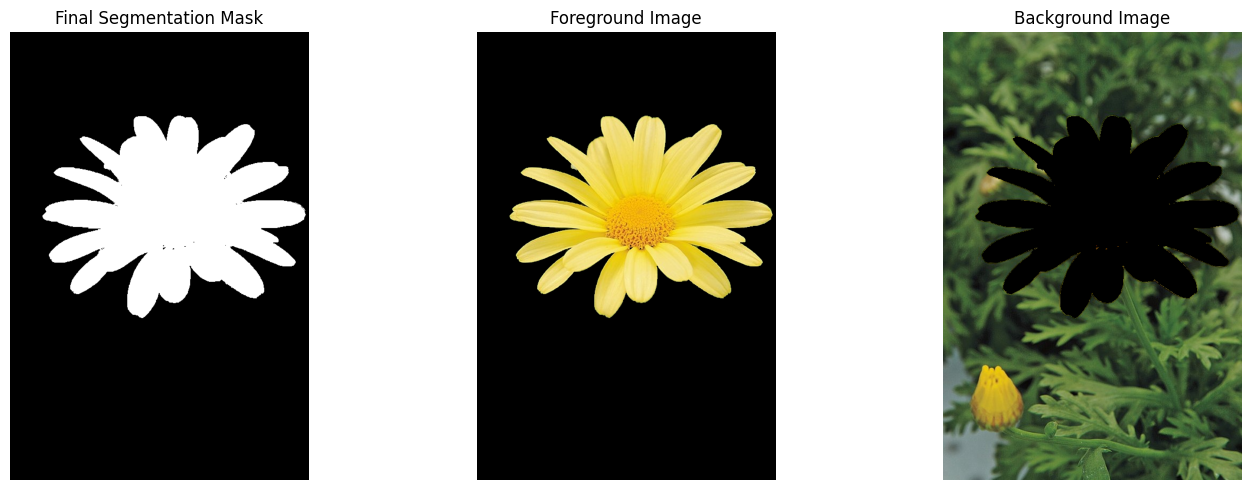

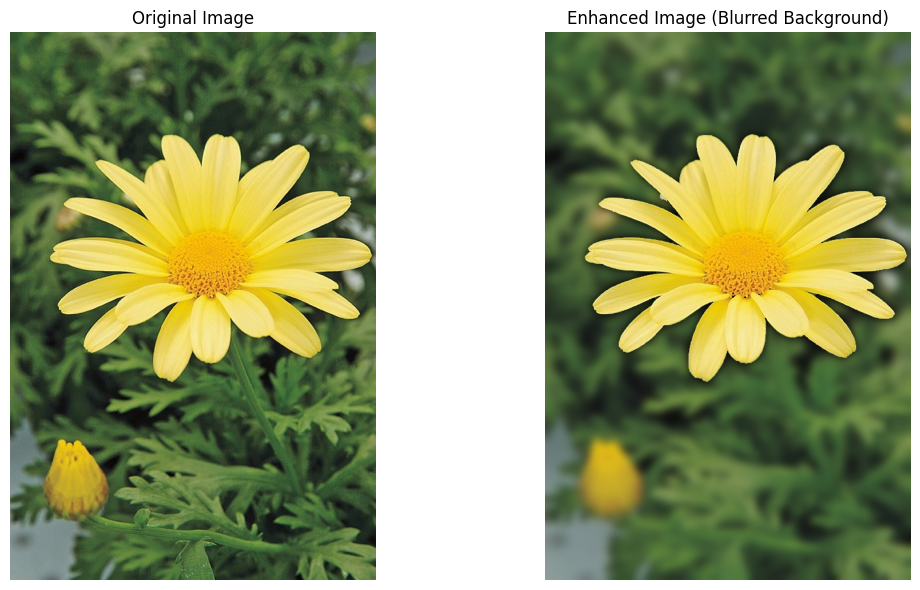

In [67]:
im9 = cv2.imread('images/q9.jpeg')
im9_rgb = cv2.cvtColor(im9, cv2.COLOR_BGR2RGB)
h, w = im9_rgb.shape[:2]

mask = np.zeros((h, w), np.uint8)
bgd_model = np.zeros((1, 65), np.float64)
fgd_model = np.zeros((1, 65), np.float64)

rect = (int(w * 0.11), int(h * 0.11), int(w * 0.95), int(h * 0.55))
cv2.grabCut(im9_rgb, mask, rect, bgd_model, fgd_model, iterCount=5, mode=cv2.GC_INIT_WITH_RECT)

binary_mask = np.where((mask == 1) | (mask == 3), 1, 0).astype('uint8')
    
foreground = cv2.bitwise_and(im9_rgb, im9_rgb, mask=binary_mask)
background = cv2.bitwise_and(im9_rgb, im9_rgb, mask=1 - binary_mask)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
outputs_a = [
    (binary_mask * 255, "Final Segmentation Mask", "gray"),
    (foreground, "Foreground Image", None),
    (background, "Background Image", None)
]

for ax, (img, title, cmap) in zip(axes, outputs_a):
    ax.imshow(img, cmap=cmap) if cmap else ax.imshow(img)
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()

blurred_back = cv2.GaussianBlur(background, (41, 41), 0)

enhanced_img = np.where(binary_mask[:, :, np.newaxis] == 1, im9_rgb, blurred_back)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
outputs_b = [
    (im9_rgb, "Original Image"),
    (enhanced_img, "Enhanced Image (Blurred Background)")
]

for ax, (img, title) in zip(axes, outputs_b):
    ax.imshow(img)
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()

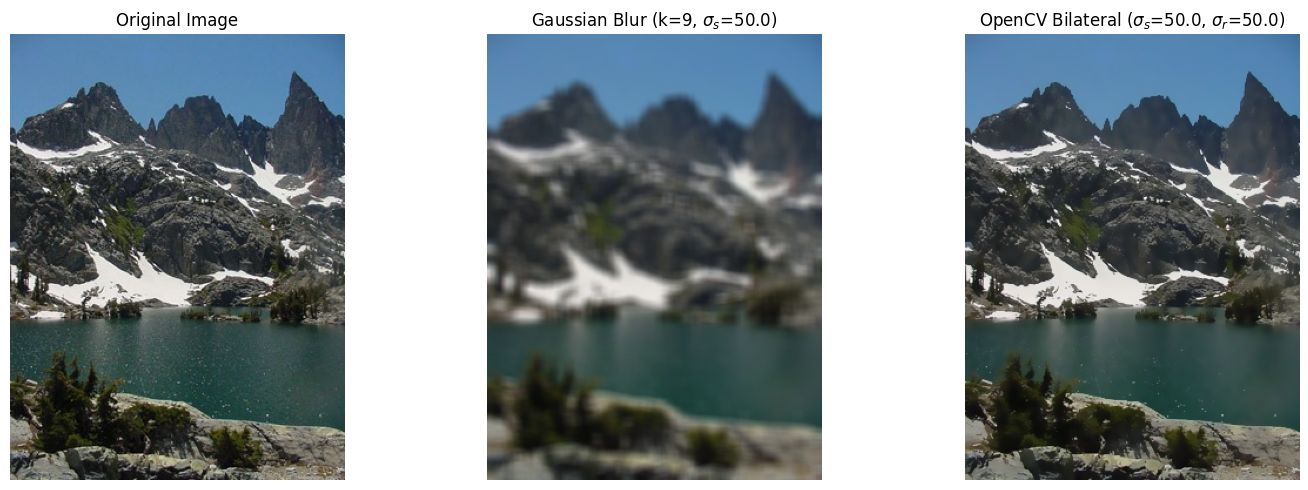

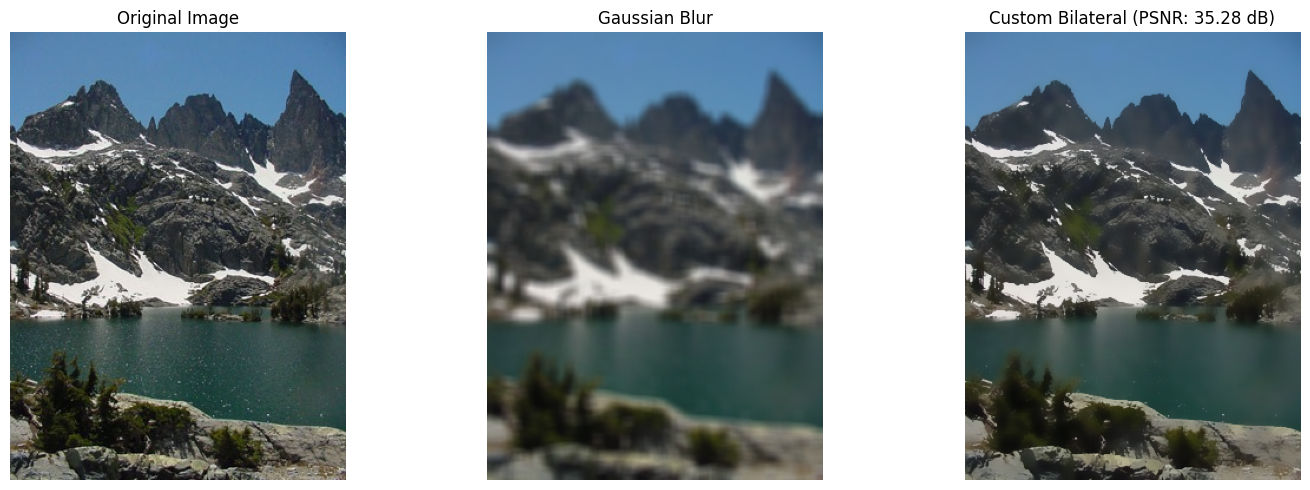

Mean Squared Error (MSE): 19.2601
Peak Signal-to-Noise Ratio (PSNR): 35.28 dB


In [71]:
im10 = cv2.imread('images/q10.jpeg')
im10_rgb = cv2.cvtColor(im10, cv2.COLOR_BGR2RGB)

d = 9             # Window size (diameter)
sigma_s = 50.0    # Spatial standard deviation (coordinate distance)
sigma_r = 50.0    # Range standard deviation (color intensity difference)

cv_bilateral = cv2.bilateralFilter(im10_rgb, d, sigma_r, sigma_s)
gaussian_blur = cv2.GaussianBlur(im10_rgb, (d, d), sigmaX=sigma_s)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
outputs_a = [
    (im10_rgb, "Original Image"),
    (gaussian_blur, rf"Gaussian Blur (k={d}, $\sigma_s$={sigma_s})"),
    (cv_bilateral, rf"OpenCV Bilateral ($\sigma_s$={sigma_s}, $\sigma_r$={sigma_r})")
]

for ax, (img, title) in zip(axes, outputs_a):
    ax.imshow(img)
    ax.set_title(title, fontsize=12)
    ax.axis('off')

plt.tight_layout()
plt.show()

def custom_bilateral_filter(image, d, sigma_r, sigma_s):
    h, w, c = image.shape
    result = np.zeros_like(image, dtype=np.float32)
    radius = d // 2
    
    y, x = np.mgrid[-radius:radius+1, -radius:radius+1]
    spatial_weights = np.exp(-(x**2 + y**2) / (2 * sigma_s**2))
    
    padded_img = np.pad(image, ((radius, radius), (radius, radius), (0, 0)), mode='reflect').astype(np.float32)
    
    for i in range(h):
        for j in range(w):
            window = padded_img[i:i+d, j:j+d, :]
            center_pixel = padded_img[i+radius, j+radius, :]
            
            color_diffs = np.sum((window - center_pixel)**2, axis=2)
            range_weights = np.exp(-color_diffs / (2 * sigma_r**2))
                
            total_weights = spatial_weights * range_weights
            weight_sum = np.sum(total_weights)
            
            for k in range(c):
                result[i, j, k] = np.sum(total_weights * window[:, :, k]) / weight_sum
                
    return np.clip(result, 0, 255).astype(np.uint8)

custom_bilateral = custom_bilateral_filter(im10_rgb, d, sigma_r, sigma_s)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
outputs_b = [
    (im10_rgb, "Original Image"),
    (gaussian_blur, "Gaussian Blur"),
    (custom_bilateral, rf"Custom Bilateral (PSNR: {psnr:.2f} dB)")
]

for ax, (img, title) in zip(axes, outputs_b):
    ax.imshow(img)
    ax.set_title(title, fontsize=12)
    ax.axis('off')

plt.tight_layout()
plt.show()

mse = np.mean((cv_bilateral.astype(np.float64) - custom_bilateral.astype(np.float64)) ** 2)

max_pixel = 255.0
psnr = 10 * np.log10((max_pixel ** 2) / mse) if mse > 0 else float('inf')
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Peak Signal-to-Noise Ratio (PSNR): {psnr:.2f} dB")